# VCR-Bench Starting Guide

This notebook shows two ways to use the project:

- notebook shell commands with `!`
- the Python API directly

For each style, it runs:

1. a clean test
2. an `ifgsm` attack
3. the same attack with `gaussian_blur`

Dataset subsets and checkpoints are resolved automatically when missing.


In [13]:
import json, subprocess, sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "pyproject.toml").exists():
    ROOT = next((p for p in [ROOT, *ROOT.parents] if (p / "pyproject.toml").exists()), ROOT)

OUT = ROOT / "notebook_outputs"
OUT.mkdir(exist_ok=True)


## Install VCR-Bench

In [14]:
%cd {ROOT}
!{sys.executable} -m pip install -e . matplotlib pandas


C:\Users\Black\Desktop\videolab\VCR_BENCHMARK\vcr-bench


Obtaining file:///C:/Users/Black/Desktop/videolab/VCR_BENCHMARK/vcr-bench
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for vcr-bench (pyproject.toml): started
  Building editable for vcr-bench (pyproject.toml): finished with status 'done'
  Created wheel for vcr-bench: filename=vcr_bench-0.1.0-0.editable-py3-none-any.whl size=7596 sha256=ad946bc4439b3f27edc04ef32acb93a46e82cd9c67b492a6bb9d19e70f7f3da8
  Stored in directory: C:\Users\Black\AppData\Local\Temp\pip-ephem-wheel-cache-8hi2uzc9\wheels\aa\3e\1c\215670e1c5ab9cf69c55


[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_PRESET = "amd"
MODEL_PRESET_NAME = "vitb_k400"
ATTACK_PRESET = "ifgsm"
DEFENCE_PRESET = "gaussian_blur"
DATASET = "kinetics400"
DATASET_SUBSET = "k400_val"
NUM_VIDEOS = 8


## Clean Test

In [16]:
accuracy_cli_json = OUT / "accuracy_cli.json"
!{sys.executable} -m vcr_bench.cli.test --model-preset {MODEL_PRESET} --model-preset-name {MODEL_PRESET_NAME} --dataset {DATASET} --dataset-subset {DATASET_SUBSET} --num-videos {NUM_VIDEOS} --device {DEVICE} --output-json {accuracy_cli_json}
accuracy_cli = json.loads(accuracy_cli_json.read_text())
accuracy_cli


{
  "correct": 6,
  "count": 8,
  "accuracy": 0.75,
  "skipped": 0,
  "elapsed_sec": 240.99732327461243,
  "model_name": "amd",
  "dataset_name": "Kinetics400Dataset"
}


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`

eval: 100%|██████████| 8/8 [04:00<00:00, 30.12s/it]


{'correct': 6,
 'count': 8,
 'accuracy': 0.75,
 'skipped': 0,
 'elapsed_sec': 240.99732327461243,
 'model_name': 'amd',
 'dataset_name': 'Kinetics400Dataset'}

## Clean Test With Python API

In [17]:
from vcr_bench.attacks import create_attack
from vcr_bench.datasets import create_dataset
from vcr_bench.defences import create_defence
from vcr_bench.models import create_model
from vcr_bench.presets import resolve_entity_preset
from vcr_bench.utils.eval import run_accuracy, run_attack

model_spec = resolve_entity_preset("model", MODEL_PRESET, preset_name=MODEL_PRESET_NAME)
attack_spec = resolve_entity_preset("attack", ATTACK_PRESET)
defence_spec = resolve_entity_preset("defence", DEFENCE_PRESET)


def make_model():
    params = dict(model_spec["params"])
    params["device"] = DEVICE
    return create_model(model_spec["factory_name"], **params)


def make_dataset():
    return create_dataset(DATASET, dataset_subset=DATASET_SUBSET, split="val")

accuracy_api = run_accuracy(model=make_model(), dataset=make_dataset(), num_videos=NUM_VIDEOS, pipeline_stage="test")
accuracy_api


eval: 100%|██████████| 8/8 [03:13<00:00, 24.21s/it]


{'correct': 6,
 'count': 8,
 'accuracy': 0.75,
 'skipped': 0,
 'elapsed_sec': 193.72375774383545,
 'model_name': 'amd',
 'dataset_name': 'Kinetics400Dataset'}

## IFGSM Attack With `!`

In [20]:
attack_cli_json = OUT / "attack_cli.json"
!{sys.executable} -m vcr_bench.cli.attack --model-preset {MODEL_PRESET} --lite-attack  --no-vmaf --model-preset-name {MODEL_PRESET_NAME} --attack-preset {ATTACK_PRESET} --dataset {DATASET} --dataset-subset {DATASET_SUBSET} --num-videos {NUM_VIDEOS} --device {DEVICE} --output-json {attack_cli_json}
attack_cli = json.loads(attack_cli_json.read_text())
attack_cli


{
  "model_name": "amd",
  "dataset_name": "Kinetics400Dataset",
  "attack_name": "ifgsm_untarget_no_defence_non-adaptive",
  "targeted": false,
  "processed": 3,
  "clear_correct": 8,
  "attacked_success": 8,
  "target_success": 0,
  "total_seen": 13,
  "skipped_misclassified": 0,
  "skipped_existing": 5,
  "skipped_errors": 0,
  "mean_time": 146.96581682562828,
  "mean_iterations": 6.0,
  "mean_psnr": 52.139458690220295,
  "mean_vmaf": 19.077515360620538,
  "save_path": "results\\attacks\\ifgsm_untarget_no_defence_non-adaptive\\amd.csv",
  "log_path": "attack_logs\\attacks\\log_attacks.csv",
  "dump_path": "results\\attacked_videos\\attacks\\ifgsm_untarget_no_defence_non-adaptive\\amd"
}



attack: 100%|██████████| 8/8 [03:41<00:00, 27.72s/it]


{'model_name': 'amd',
 'dataset_name': 'Kinetics400Dataset',
 'attack_name': 'ifgsm_untarget_no_defence_non-adaptive',
 'targeted': False,
 'processed': 3,
 'clear_correct': 8,
 'attacked_success': 8,
 'target_success': 0,
 'total_seen': 13,
 'skipped_misclassified': 0,
 'skipped_existing': 5,
 'skipped_errors': 0,
 'mean_time': 146.96581682562828,
 'mean_iterations': 6.0,
 'mean_psnr': 52.139458690220295,
 'mean_vmaf': 19.077515360620538,
 'save_path': 'results\\attacks\\ifgsm_untarget_no_defence_non-adaptive\\amd.csv',
 'log_path': 'attack_logs\\attacks\\log_attacks.csv',
 'dump_path': 'results\\attacked_videos\\attacks\\ifgsm_untarget_no_defence_non-adaptive\\amd'}

## IFGSM Attack With Python API

In [21]:
attack_api = run_attack(
    model=make_model(),
    attack=create_attack(attack_spec["factory_name"], **attack_spec["params"]),
    dataset=make_dataset(),
    save_path=OUT / "attack_api.csv",
    log_path=None,
    attack_name="ifgsm_api",
    num_videos=NUM_VIDEOS,
    pipeline_stage="attack",
)
attack_api


attack:  12%|█▎        | 1/8 [01:16<08:53, 76.17s/it]


KeyboardInterrupt: 

## attack IFGSM + defence Gaussian Blur 

In [24]:
defence_cli_json = OUT / "defence_cli.json"
!{sys.executable} -m vcr_bench.cli.attack --model-preset {MODEL_PRESET} --no-vmaf --lite-attack --model-preset-name {MODEL_PRESET_NAME} --attack-preset {ATTACK_PRESET} --defence-preset {DEFENCE_PRESET} --dataset {DATASET} --dataset-subset {DATASET_SUBSET} --num-videos {NUM_VIDEOS} --device {DEVICE} --output-json {defence_cli_json}
defence_cli = json.loads(defence_cli_json.read_text())
defence_cli


{
  "model_name": "amd",
  "dataset_name": "Kinetics400Dataset",
  "attack_name": "ifgsm_untarget_gaussian_blur_non-adaptive",
  "targeted": false,
  "processed": 6,
  "clear_correct": 12,
  "attacked_success": 7,
  "target_success": 0,
  "total_seen": 18,
  "skipped_misclassified": 2,
  "skipped_existing": 0,
  "skipped_errors": 0,
  "mean_time": 35.74896812438965,
  "mean_iterations": 3.1666666666666665,
  "mean_psnr": 52.44613771323227,
  "mean_vmaf": 0.0,
  "save_path": "results\\attacks\\ifgsm_untarget_gaussian_blur_non-adaptive\\amd.csv",
  "log_path": "attack_logs\\attacks\\log_attacks.csv",
  "dump_path": "results\\attacked_videos\\attacks\\ifgsm_untarget_gaussian_blur_non-adaptive\\amd"
}



attack: 100%|██████████| 8/8 [06:49<00:00, 51.13s/it]


{'model_name': 'amd',
 'dataset_name': 'Kinetics400Dataset',
 'attack_name': 'ifgsm_untarget_gaussian_blur_non-adaptive',
 'targeted': False,
 'processed': 6,
 'clear_correct': 12,
 'attacked_success': 7,
 'target_success': 0,
 'total_seen': 18,
 'skipped_misclassified': 2,
 'skipped_existing': 0,
 'skipped_errors': 0,
 'mean_time': 35.74896812438965,
 'mean_iterations': 3.1666666666666665,
 'mean_psnr': 52.44613771323227,
 'mean_vmaf': 0.0,
 'save_path': 'results\\attacks\\ifgsm_untarget_gaussian_blur_non-adaptive\\amd.csv',
 'log_path': 'attack_logs\\attacks\\log_attacks.csv',
 'dump_path': 'results\\attacked_videos\\attacks\\ifgsm_untarget_gaussian_blur_non-adaptive\\amd'}

## IFGSM + Gaussian Blur With Python API

In [ ]:
defence_api = run_attack(
    model=make_model(),
    attack=create_attack(attack_spec["factory_name"], **attack_spec["params"]),
    dataset=make_dataset(),
    save_path=OUT / "defence_api.csv",
    log_path=None,
    attack_name="ifgsm_blur_api",
    num_videos=NUM_VIDEOS,
    pipeline_stage="attack",
    defence=create_defence(defence_spec["factory_name"], **defence_spec["params"]),
)
defence_api


## Compare CLI And Python API Results

In [25]:
def attack_success_rate(summary):
    denom = max(int(summary.get("clear_correct", 0)), 1)
    return float(summary.get("attacked_success", 0)) / denom

comparison = pd.DataFrame([
    {"source": "cli", "run": "clean", "accuracy": float(accuracy_cli.get("accuracy", 0.0))},
    {"source": "api", "run": "clean", "accuracy": float(accuracy_api.get("accuracy", 0.0))},
    {"source": "cli", "run": "ifgsm", "attack_success_rate": attack_success_rate(attack_cli), "psnr": float(attack_cli.get("mean_psnr", 0.0))},
    {"source": "api", "run": "ifgsm", "attack_success_rate": attack_success_rate(attack_api), "psnr": float(attack_api.get("mean_psnr", 0.0))},
    {"source": "cli", "run": "ifgsm+blur", "attack_success_rate": attack_success_rate(defence_cli), "psnr": float(defence_cli.get("mean_psnr", 0.0))},
    {"source": "api", "run": "ifgsm+blur", "attack_success_rate": attack_success_rate(defence_api), "psnr": float(defence_api.get("mean_psnr", 0.0))},
])
comparison


NameError: name 'attack_api' is not defined

NameError: name 'comparison' is not defined

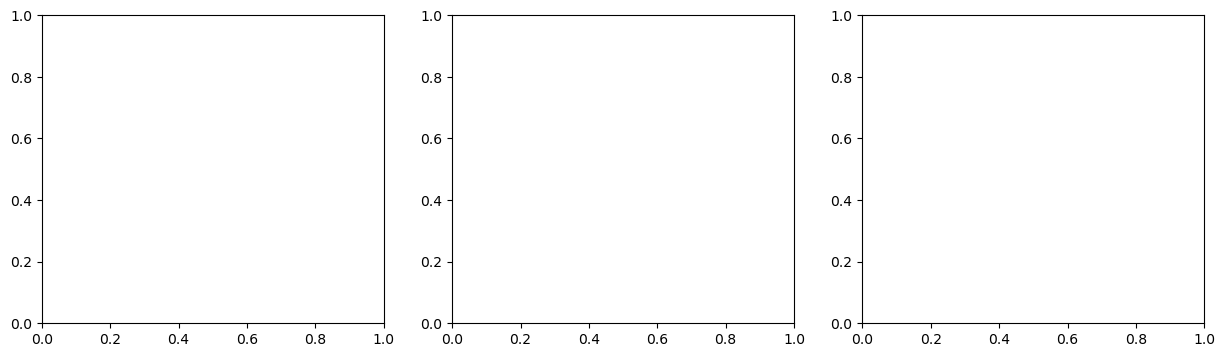

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

clean = comparison[comparison.run == "clean"]
axes[0].bar(clean["source"], clean["accuracy"].fillna(0))
axes[0].set_title("Clean Accuracy")
axes[0].set_ylim(0, 1)

attack_runs = comparison[comparison["attack_success_rate"].notna()]
labels = attack_runs["source"] + "-" + attack_runs["run"]
axes[1].bar(labels, attack_runs["attack_success_rate"])
axes[1].set_title("Attack Success Rate")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=30)

axes[2].bar(labels, attack_runs["psnr"])
axes[2].set_title("Mean PSNR")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


## Inspect Per-Video Rows

The CLI and Python API attack summaries include `save_path`, so you can open the generated CSV files the same way.


In [27]:
pd.read_csv(attack_cli["save_path"])[["video_name", "clear_class", "attacked_class", "psnr", "vmaf", "time"]].head()


,video_name,clear_class,attacked_class,psnr,vmaf,time
0,/mnt/c/Users/Black/Desktop/videolab/video_clas...,259,330,54.750668,71.292652,4.177558
1,/mnt/c/Users/Black/Desktop/videolab/video_clas...,203,352,54.750668,81.327471,5.320661
2,/mnt/c/Users/Black/Desktop/videolab/VCR_BENCHM...,338,338,0.000000,0.000000,7.748478
3,/mnt/c/Users/Black/Desktop/videolab/VCR_BENCHM...,308,308,0.000000,0.000000,7.654801
4,/mnt/c/Users/Black/Desktop/videolab/VCR_BENCHM...,329,329,0.000000,0.000000,11.150931


## Next Steps

- Change `MODEL_PRESET` and `MODEL_PRESET_NAME` to try another model.
- Replace `ATTACK_PRESET` with another attack preset.
- Replace `DEFENCE_PRESET` with another defence preset.
- Inspect attack-specific flags with `python -m vcr_bench.cli.attack --attack square --print-attack-spec`.
